# TUGAS PRAKTIKUM - DATA MINING


**Topik:** Klasifikasi Prediksi Pembelian E-Commerce Menggunakan Algoritma C4.5  
**Program Studi:** Teknik Informatika  
**Universitas:** Universitas Pelita Bangsa

**Anggota Kelompok:**
1. Gilang Prayoga (312310232)
2. Rifqi Putra Adhadi (312310281)
3. Adira Alvian Zein (312310263)

---
* **Dataset:** Online Shoppers Purchasing Intention
* **Algoritma:** C4.5 (Decision Tree)  
* **Tujuan:**
  1. Memprediksi apakah pengunjung web akan melakukan transaksi pembelian (Revenue: True/False) berdasarkan data perilaku *browsing*.
  2. Mengidentifikasi fitur atau faktor perilaku apa yang paling berpengaruh (seperti kualitas UI/UX halaman web) terhadap keputusan pembelian, guna memberikan rekomendasi strategi bisnis e-commerce.


# TAHAP 1 : DATA UNDERSTANDING


In [ ]:

# ---------------------------------------------------------------------
# 1. Unduh Dataset dari Google Drive & Load ke DataFrame
# ---------------------------------------------------------------------
import gdown
import pandas as pd

# TODO: Silakan ganti ID di bawah ini dengan ID unik file Google Drive kelompok Anda
file_id = '1ZFTsU_zCHPGoPkdROqH_CChvcfhS3zq5'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'online_shoppers_intention.csv'

# Proses download otomatis
gdown.download(url, output, quiet=False)

# Membaca dataset menggunakan pandas
df = pd.read_csv(output)

# Menampilkan 5 baris pertama dataset
print("--- 5 BARIS PERTAMA DATASET ---")
df.head()

Downloading...
From: https://drive.google.com/uc?id=1ZFTsU_zCHPGoPkdROqH_CChvcfhS3zq5
To: /content/online_shoppers_intention.csv
100%|██████████| 1.07M/1.07M [00:00<00:00, 87.8MB/s]


--- 5 BARIS PERTAMA DATASET ---


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
# ---------------------------------------------------------------------
# 2. Menampilkan Jumlah Data dan Tipe Data
# ---------------------------------------------------------------------
print("--- INFORMASI DATASET (JUMLAH & TIPE DATA) ---")
df.info()

--- INFORMASI DATASET (JUMLAH & TIPE DATA) ---
<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  int64  
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non


# TAHAP 2 : DATA PREPROCESSING


In [ ]:

# ---------------------------------------------------------------------
# 1. Pengecekan Missing Value (Data Kosong)
# ---------------------------------------------------------------------
print("--- PENGECEKAN MISSING VALUE ---")
# Menampilkan jumlah data yang kosong di setiap kolom
missing_data = df.isnull().sum()
print(missing_data)

# Kesimpulan otomatis
if missing_data.sum() == 0:
    print("\n[INFO] Data aman! Tidak ditemukan missing value.")
else:
    print(f"\n[INFO] Ditemukan total {missing_data.sum()} missing value. Perlu penanganan.")

# ---------------------------------------------------------------------
# 2. Pengecekan Data Duplikat (Anomali)
# ---------------------------------------------------------------------
print("\n--- PENGECEKAN DATA DUPLIKAT ---")
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat ditemukan: {jumlah_duplikat}")

# Proses menghapus anomali duplikat (jika ada)
if jumlah_duplikat > 0:
    df = df.drop_duplicates()
    print("[INFO] Data duplikat telah berhasil dihapus!")
    print(f"Jumlah baris data sekarang menjadi: {df.shape[0]} baris.")
else:
    print("[INFO] Tidak ada data duplikat. Data sudah bersih.")

--- PENGECEKAN MISSING VALUE ---
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

[INFO] Data aman! Tidak ditemukan missing value.

--- PENGECEKAN DATA DUPLIKAT ---
Jumlah baris duplikat ditemukan: 125
[INFO] Data duplikat telah berhasil dihapus!
Jumlah baris data sekarang menjadi: 12205 baris.


In [ ]:
# ---------------------------------------------------------------------
# 3. Encoding Data Kategorikal (Mengubah Teks menjadi Angka)
# ---------------------------------------------------------------------
print("--- PROSES ENCODING DATA ---")
from sklearn.preprocessing import LabelEncoder

# Inisialisasi fungsi LabelEncoder
le = LabelEncoder()

# 1. Mengubah kolom teks menjadi angka
df['Month'] = le.fit_transform(df['Month'])
df['VisitorType'] = le.fit_transform(df['VisitorType'])

# 2. Mengubah kolom Boolean (True/False) menjadi angka (1/0)
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

print("[INFO] Encoding selesai! Semua data teks dan boolean sudah menjadi angka.")

# Menampilkan 5 baris pertama untuk memastikan perubahannya
print("\n--- HASIL SETELAH ENCODING ---")
df.head()

--- PROSES ENCODING DATA ---
[INFO] Encoding selesai! Semua data teks dan boolean sudah menjadi angka.

--- HASIL SETELAH ENCODING ---


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,1,0


In [ ]:
# ---------------------------------------------------------------------
# 4. Pemisahan Data (Data Splitting) - Akhir Tahap 2
# ---------------------------------------------------------------------
print("--- PROSES PEMISAHAN DATA (DATA SPLITTING) ---")
from sklearn.model_selection import train_test_split

# Memisahkan Fitur (X) dan Target/Label (y)
# X berisi semua kolom KECUALI kolom 'Revenue'
X = df.drop('Revenue', axis=1)
# y HANYA berisi kolom 'Revenue' (target yang mau ditebak)
y = df['Revenue']

# Membagi data: 80% untuk Training (Belajar) dan 20% untuk Testing (Ujian)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total data keseluruhan : {len(df)} baris")
print(f"Jumlah Data Training   : {len(X_train)} baris (80%)")
print(f"Jumlah Data Testing    : {len(X_test)} baris (20%)")

--- PROSES PEMISAHAN DATA (DATA SPLITTING) ---
Total data keseluruhan : 12205 baris
Jumlah Data Training   : 9764 baris (80%)
Jumlah Data Testing    : 2441 baris (20%)


### Analisis & Catatan Preprocessing Data:
* **Pembersihan Data:** Pengecekan menunjukkan bahwa dataset bersih dari *missing value*. Namun, algoritma mendeteksi adanya **125 baris data duplikat (anomali)** yang jika dibiarkan dapat membuat model bias. Baris duplikat tersebut telah berhasil dihapus secara otomatis, menyisakan total **12.205 baris data bersih**.
* **Encoding Kategorikal:** Fitur berbasis teks seperti `Month` dan `VisitorType` serta nilai boolean `Weekend` dan `Revenue` berhasil diubah menjadi representasi angka (0, 1, 2, dst.) agar dapat diproses oleh perhitungan matematika pohon keputusan C4.5.
* **Pemisahan Data (Data Splitting):** Data bersih dibagi menggunakan proporsi standar data mining (80:20), menghasilkan **9.764 baris** untuk melatih model (*Data Training*) dan **2.441 baris** untuk menguji performa model (*Data Testing*).


# TAHAP 3 : IMPLEMENTASI ALGORITMA (C4.5 / DECISION TREE)


In [ ]:


print("\n--- IMPLEMENTASI ALGORITMA C4.5 ---")
from sklearn.tree import DecisionTreeClassifier

# 1. Inisialisasi Model C4.5
# Catatan untuk presentasi: C4.5 secara teori menggunakan 'entropy' (Information Gain)
# untuk memecah cabang pohon. Kita batasi kedalaman (max_depth) agar tidak overfitting.
model_c45 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

# Menampilkan parameter yang digunakan (Sesuai rubrik UAS)
print("Parameter yang digunakan:")
print(model_c45.get_params())

# 2. Melatih Model dengan Data Training (Proses Belajar)
model_c45.fit(X_train, y_train)

print("\n[INFO] Model C4.5 berhasil dilatih dengan Data Training!")


--- IMPLEMENTASI ALGORITMA C4.5 ---
Parameter yang digunakan:
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


NameError: name 'X_train' is not defined


# TAHAP 4 : EVALUASI HASIL



--- EVALUASI KINERJA MODEL C4.5 ---
Akurasi Model: 89.76%

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2079
           1       0.73      0.49      0.58       362

    accuracy                           0.90      2441
   macro avg       0.82      0.73      0.76      2441
weighted avg       0.89      0.90      0.89      2441


--- CONFUSION MATRIX ---


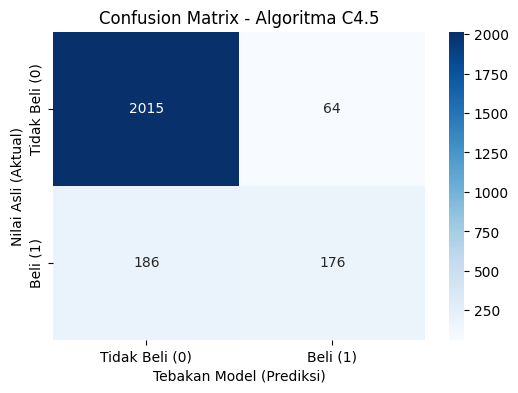

In [ ]:

print("\n--- EVALUASI KINERJA MODEL C4.5 ---")
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Melakukan Prediksi dengan Data Testing (Ujian Algoritma)
y_pred = model_c45.predict(X_test)

# 2. Menampilkan Akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {akurasi * 100:.2f}%\n")

# 3. Menampilkan Classification Report (F1-Score, Presisi, Recall)
print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

# 4. Visualisasi Confusion Matrix
print("\n--- CONFUSION MATRIX ---")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Beli (0)', 'Beli (1)'],
            yticklabels=['Tidak Beli (0)', 'Beli (1)'])
plt.title('Confusion Matrix - Algoritma C4.5')
plt.ylabel('Nilai Asli (Aktual)')
plt.xlabel('Tebakan Model (Prediksi)')
plt.show()


### Analisis Kinerja dan Evaluasi Model C4.5:
* **Akurasi Global (89.76%):** Model klasifikasi C4.5 menunjukkan performa yang sangat kuat. Dari seluruh data uji yang diberikan, model mampu menebak dengan benar status pembelian pengunjung hingga mendekati angka 90%.
* **Interpretasi Klasifikasi & Confusion Matrix:**
  * **Kelas 0 (Tidak Beli):** Model sangat superior dalam mendeteksi pengunjung yang dari awal hanya berniat melihat-lihat (*window shopping*) tanpa membeli, dibuktikan dengan nilai *Recall* mencapai 97% (kotak biru kiri-atas sangat dominan).
  * **Kelas 1 (Beli):** Untuk mendeteksi pembeli riil, model menghasilkan *Precision* 73% dan *Recall* 49% (*F1-Score* 0.58). Hal ini mencerminkan tantangan nyata di dunia e-commerce, di mana tindakan *checkout* transaksi sering kali dipengaruhi faktor eksternal mendadak yang polanya lebih dinamis untuk ditebak oleh algoritma.


# TAHAP 5 : VISUALISASI


###1. Visualisai Pohon Keputusan / Plot Tree (menunjukkan alur logika/aturan algoritma).


--- VISUALISASI POHON KEPUTUSAN (DECISION TREE) ---


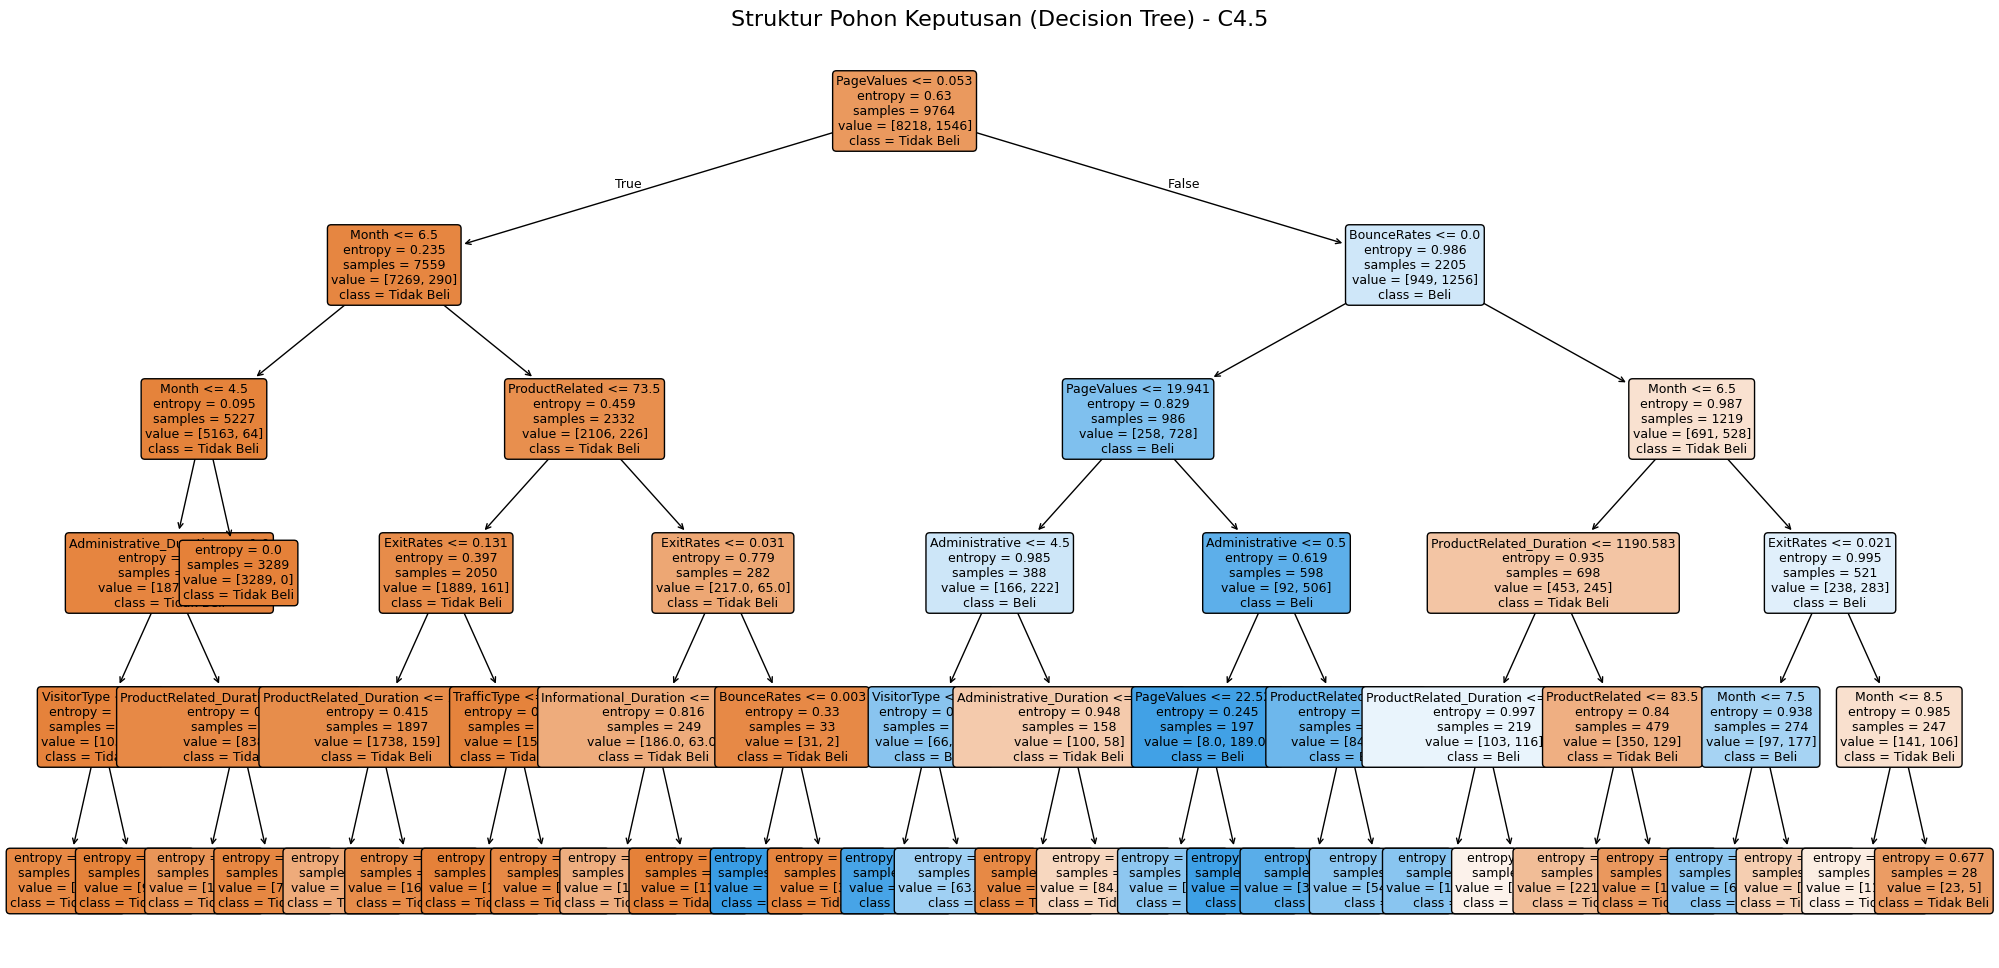

In [ ]:

print("\n--- VISUALISASI POHON KEPUTUSAN (DECISION TREE) ---")
from sklearn.tree import plot_tree

# Menggambar pohon keputusan
plt.figure(figsize=(25, 12)) # Ukuran gambar diperbesar agar teks terbaca
plot_tree(model_c45,
          feature_names=X.columns,
          class_names=['Tidak Beli', 'Beli'],
          filled=True,
          rounded=True,
          fontsize=9)
plt.title('Struktur Pohon Keputusan (Decision Tree) - C4.5', fontsize=16)
plt.show()

###2. Visualisasi Feature Importance (menunjukkan faktor utama alasan pengunjung berbelanja).


--- VISUALISASI FEATURE IMPORTANCE ---


/tmp/ipykernel_881/1347574295.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Skor Kepentingan', y='Fitur', data=df_importance, palette='viridis')


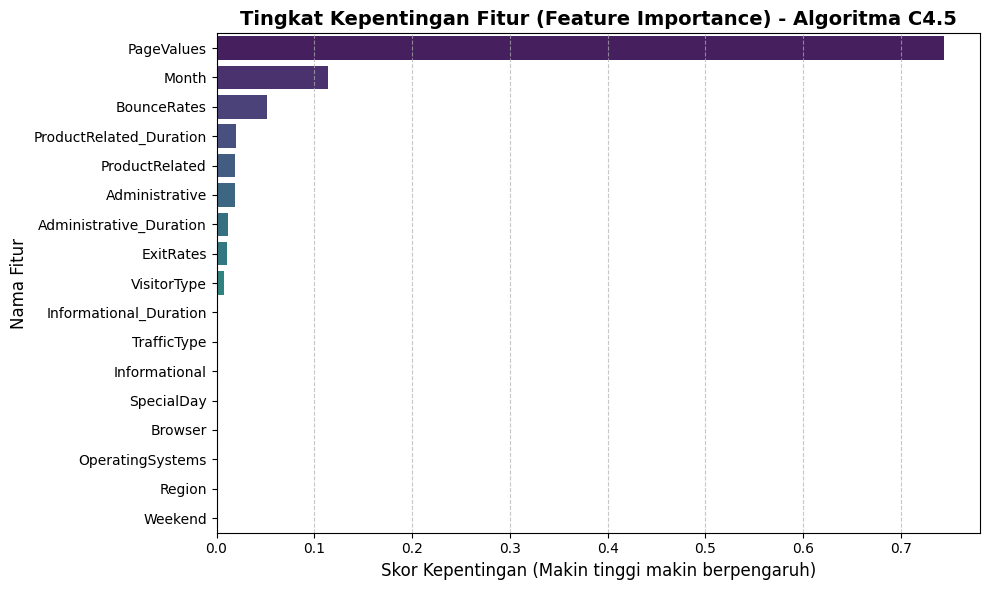


[INSIGHT PRESENTASI]: Berdasarkan algoritma C4.5, fitur yang paling menentukan
apakah pengunjung akan membeli atau tidak adalah 'PageValues'.


In [ ]:

print("\n--- VISUALISASI FEATURE IMPORTANCE ---")
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Mengambil nilai tingkat kepentingan fitur dari model C4.5 yang sudah dilatih
importances = model_c45.feature_importances_
nama_fitur = X.columns

# 2. Menggabungkan ke dalam DataFrame agar rapi dan mengurutkannya dari yang paling penting
df_importance = pd.DataFrame({'Fitur': nama_fitur, 'Skor Kepentingan': importances})
df_importance = df_importance.sort_values(by='Skor Kepentingan', ascending=False)

# 3. Membuat visualisasi Bar Chart (Grafik Batang)
plt.figure(figsize=(10, 6))
# Menggunakan palet warna yang menarik dan profesional
sns.barplot(x='Skor Kepentingan', y='Fitur', data=df_importance, palette='viridis')

plt.title('Tingkat Kepentingan Fitur (Feature Importance) - Algoritma C4.5', fontsize=14, fontweight='bold')
plt.xlabel('Skor Kepentingan (Makin tinggi makin berpengaruh)', fontsize=12)
plt.ylabel('Nama Fitur', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Menampilkan penjelasan otomatis untuk bahan presentasi
fitur_utama = df_importance.iloc[0]['Fitur']
print(f"\n[INSIGHT PRESENTASI]: Berdasarkan algoritma C4.5, fitur yang paling menentukan")
print(f"apakah pengunjung akan membeli atau tidak adalah '{fitur_utama}'.")

### Analisis Visualisasi dan Aturan Bisnis (Insight):

* **Logika Aturan Pohon Keputusan:** Struktur pohon keputusan menempatkan `PageValues` sebagai akar utama (*root node*). Jika seorang pengunjung mengakses halaman web dengan nilai kontribusi transaksi yang tinggi (`PageValues` > nilai ambang batas tertentu), aliran logika pohon akan langsung mengarah pada probabilitas tinggi bahwa pengunjung tersebut akan melakukan pembelian (**Revenue = 1**). Rekomendasi bisnisnya adalah perusahaan e-commerce harus fokus meningkatkan kualitas informasi dan UI/UX pada halaman-halaman yang memiliki nilai konversi tinggi ini.
* **Faktor Penentu Utama (Feature Importance):** Hasil visualisasi grafik batang membuktikan secara mutlak bahwa fitur **`PageValues` (Nilai Halaman)** merupakan indikator paling krusial dan berpengaruh dalam model C4.5 untuk menentukan apakah pengunjung akan berbelanja atau tidak. Aturan penentu berikutnya dipengaruhi oleh durasi melihat produk (`ProductRelated_Duration`) dan tingkat kepuasan halaman (`ExitRates`).

# Kesimpulan

Berdasarkan analisis klasifikasi menggunakan algoritma C4.5, disimpulkan bahwa kualitas dan nilai konversi suatu halaman web (**`PageValues`**) merupakan indikator paling krusial dalam menentukan keputusan pembelian pengunjung. Hal ini membuktikan bahwa perancangan **UI/UX yang profesional dan terpercaya** sangat berdampak langsung pada penjualan bisnis digital. Antarmuka yang memikat dan pengalaman navigasi yang mulus terbukti secara data mampu menurunkan tingkat pengunjung yang langsung keluar (*ExitRates*) sekaligus meningkatkan durasi interaksi produk (*ProductRelated_Duration*), yang pada akhirnya sukses meyakinkan pengunjung biasa untuk melakukan transaksi.